# Production Screening Workflow (Run Mode)

Learn how to deploy LearnM8 for real-world screening with expensive measurements.

**Scenario:**
- Large compound library (30K real compounds, ID + SMILES only)
- Expensive oracle (pharmacophore matching as proxy for assay)
- Goal: Find top performers with minimal measurements
- Budget: ~1000 measurements maximum

**What you'll learn:**
- Hierarchical screening (fast → slow oracles)
- Design space pruning between stages
- Caching strategies for 100x speedup
- Checkpointing and recovery
- Result export and analysis

**Key Note:**
- **Run Mode**: Oracles generate scores on-the-fly (no ground truth)
- **Metrics**: Selection quality metrics (avg scores, not enrichment)
- **Focus**: Production workflow optimization and measurement efficiency

**Time estimate:** 20 minutes

## Section 1: Problem Setup

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('../..'))

from learnm8 import run_active_learning
from examples.oracles import SimilarityOracle
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load large library (30K real compounds, ID + SMILES only)
# In production, this would be 100K+ compounds
large_library = pl.read_csv('../data/ampc_30k_no_scores.csv')

print(f"Library size: {len(large_library):,} compounds")
print(f"Columns: {large_library.columns}")
print(f"\nGoal: Find top 100 binders")
print(f"Measurement budget: 1000 compounds")
print(f"Strategy: Hierarchical screening (fast → slow)")

# Setup persistent cache
cache_dir = Path('.cache')
cache_dir.mkdir(exist_ok=True)

Library size: 29,054 compounds
Columns: ['ID', 'SMILES']

Goal: Find top 100 binders
Measurement budget: 1000 compounds
Strategy: Hierarchical screening (fast → slow)


## Section 2: Stage 1 - Fast Filtering

In [2]:
# Stage 1: Fast 2D similarity screening (100% → 10%)
print("\n=== Stage 1: Fast Similarity Filter ===")

similarity_oracle = SimilarityOracle(
    reference_smiles='c1ccc(cc1)C(=O)O',  # Benzoic acid scaffold
    fingerprint_type='morgan',
    metric='tanimoto'
)

stage1_results = run_active_learning(
    compound_pool=large_library,
    oracle=similarity_oracle,
    target_col='similarity',
    learner='rf',
    featurizer_type='morgan',
    n_cycles=10,
    batch_fraction=0.01,  # 1% per cycle
    cache_dir=cache_dir,
    score_direction='higher',  # Higher similarity is better
	output_dir='results/stage1_results'
)

print(f"✓ Stage 1 complete")
print(f"  Measurements: {len(stage1_results['labeled_data'])}")

/home/tony/miniconda3/envs/learnm8_full/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== Stage 1: Fast Similarity Filter ===


100%|██████████| 29054/29054 [00:07<00:00, 4022.21it/s]



✓ Stage 1 complete
  Measurements: 2910


## Section 3: Stage 2 - ML-Guided Selection

In [7]:
# Get top 10% by similarity for Stage 2
print("\n=== Stage 2: ML-Guided Selection ===")

# Sort by predicted similarity (from last cycle of Stage 1) and take top 10%
# Stage 1 had 3 cycles, so we use 'prediction_cycle_3'
stage1_df = stage1_results['compounds_df']
top_10_percent = int(len(large_library) * 0.1)
pruned_indices = stage1_df.sort('prediction_cycle_9', descending=True).head(top_10_percent)

pruned_pool = large_library.join(
    pruned_indices.select(['ID']),
    on='ID',
    how='inner'
)

print(f"Pruned library: {len(large_library):,} → {len(pruned_pool):,} compounds")

# Stage 2: Intensive ML-guided screening with "expensive" oracle
# In production, this would be a real expensive oracle (docking, assay, etc.)
# Here we simulate with a more complex pharmacophore oracle
from examples.oracles import Pharmacophore2DOracle
from learnm8 import CycleConfig

expensive_oracle = Pharmacophore2DOracle(
    reference_smiles='c1ccc(cc1)C(=O)N[C@H](C)C(=O)O',  # More complex target
    metric='tanimoto'
)

stage2_results = run_active_learning(
	compound_pool=pruned_pool,
	oracle=expensive_oracle,
	target_col='pharmacophore_score',
	learner='rf_ensemble',
	featurizer_type='morgan',
	cycles=[
		CycleConfig('random', n_cycles=1, batch_fraction=0.01),
		# Smooth descent from beta=100 to beta=1 over 9 cycles (Total 10 cycles)
		CycleConfig('ucb', n_cycles=3, batch_fraction=0.01, acquisition_params={'beta': 10.0}), # Extreme exploration
		CycleConfig('greedy', n_cycles=6, batch_fraction=0.01)
	],
	cache_dir=cache_dir,
	score_direction='higher',
	export_csv=True,
	output_dir='results/stage2_results'
)

print(f"✓ Stage 2 complete")
print(f"  Measurements: {len(stage2_results['labeled_data'])}")
print(f"  Top score: {stage2_results['labeled_data']['pharmacophore_score'].max():.3f}")


=== Stage 2: ML-Guided Selection ===
Pruned library: 29,054 → 2,905 compounds


  0%|          | 0/2905 [00:00<?, ?it/s]

100%|██████████| 2905/2905 [00:00<00:00, 9586.71it/s] 
/home/tony/LearnM8/learnm8/api.py:695: UserWarning: Invalid cycle parameters ignored: export_csv. Valid cycle parameters are: acquisition_params, pruning_params, pruning_strategy. These parameters have no effect and will be removed in a future version.
  cycle_schedule = parse_cycle_schedule(
Invalid cycle parameters ignored: export_csv
100%|██████████| 2905/2905 [00:00<00:00, 9586.71it/s] 
/home/tony/LearnM8/learnm8/api.py:695: UserWarning: Invalid cycle parameters ignored: export_csv. Valid cycle parameters are: acquisition_params, pruning_params, pruning_strategy. These parameters have no effect and will be removed in a future version.
  cycle_schedule = parse_cycle_schedule(
Invalid cycle parameters ignored: export_csv


✓ Stage 2 complete
  Measurements: 300
  Top score: 0.377


## Section 4: Final Analysis (Run Mode Metrics)


=== Final Results ===
Total measurements: 3210
Identified top 100 predicted candidates
Measurement efficiency: 9.1x reduction

Stage 2 Selection Quality:
  Average score (selected): 0.106
  Top score found: 0.377
  Score std dev: 0.065


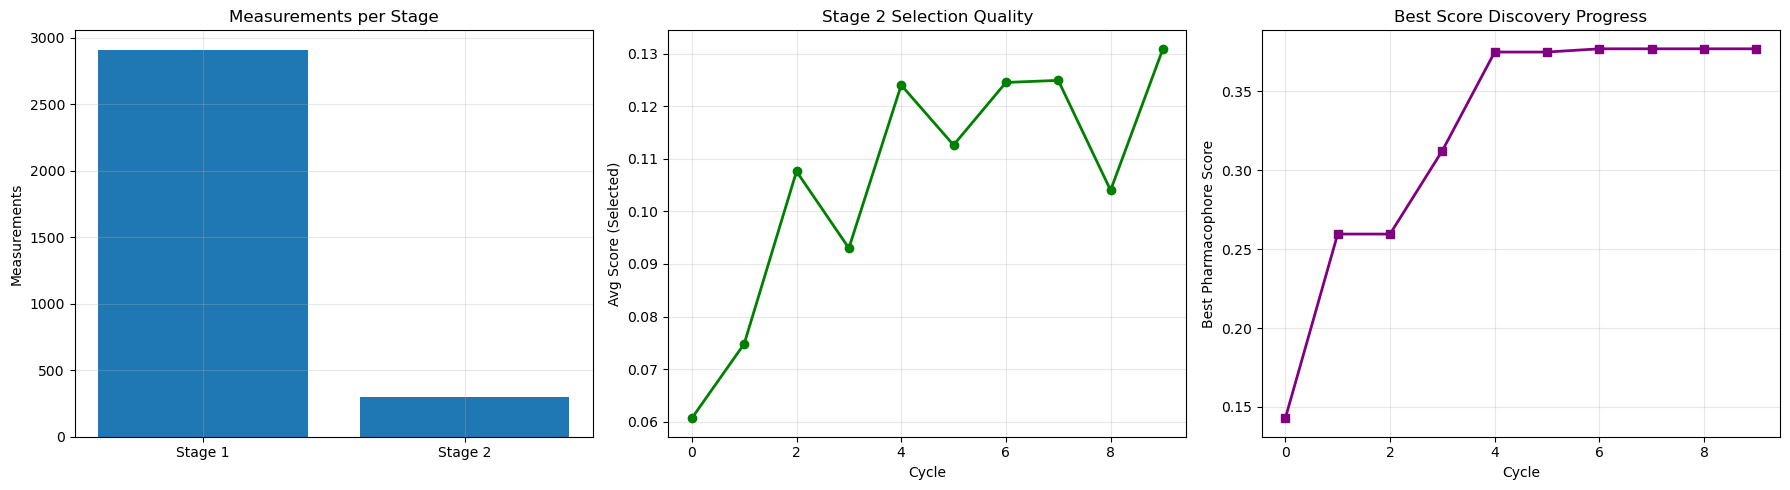

In [8]:
# Identify top candidates based on predictions
print("\n=== Final Results ===")

# Stage 2 had 5 cycles, so we use 'prediction_cycle_5'
final_predictions = stage2_results['compounds_df'].sort('prediction_cycle_5', descending=True)
top_100_candidates = final_predictions.head(100)

# Calculate measurement efficiency
total_measurements = (
    len(stage1_results['labeled_data']) +
    len(stage2_results['labeled_data'])
)

print(f"Total measurements: {total_measurements}")
print(f"Identified top 100 predicted candidates")
print(f"Measurement efficiency: {len(large_library) / total_measurements:.1f}x reduction")

# RUN MODE: Report selection quality (not enrichment)
stage2_measured = stage2_results['labeled_data']
print(f"\nStage 2 Selection Quality:")
print(f"  Average score (selected): {stage2_measured['pharmacophore_score'].mean():.3f}")
print(f"  Top score found: {stage2_measured['pharmacophore_score'].max():.3f}")
print(f"  Score std dev: {stage2_measured['pharmacophore_score'].std():.3f}")

# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Stage comparison
stage_data = pd.DataFrame({
    'Stage': ['Stage 1', 'Stage 2'],
    'Measurements': [
        len(stage1_results['labeled_data']),
        len(stage2_results['labeled_data'])
    ],
    'Compounds': [len(large_library), len(pruned_pool)]
})

axes[0].bar(stage_data['Stage'], stage_data['Measurements'])
axes[0].set_ylabel('Measurements')
axes[0].set_title('Measurements per Stage')
axes[0].grid(True, alpha=0.3)

# Selection quality over time (RUN MODE)
stage2_metrics = pd.DataFrame(stage2_results['cycle_metrics'])
axes[1].plot(stage2_metrics['cycle'], stage2_metrics['avg_score_selected'],
             marker='o', linewidth=2, color='green')
axes[1].set_xlabel('Cycle')
axes[1].set_ylabel('Avg Score (Selected)')
axes[1].set_title('Stage 2 Selection Quality')
axes[1].grid(True, alpha=0.3)

# Best score discovery progress
stage2_measured = stage2_results['labeled_data']
stage2_best_scores = []
for cycle_num in range(len(stage2_metrics)):
    cycle_measured = stage2_measured.filter(pl.col('labeled_cycle') <= cycle_num)
    stage2_best_scores.append(cycle_measured['pharmacophore_score'].max())

axes[2].plot(stage2_metrics['cycle'], stage2_best_scores,
             marker='s', linewidth=2, color='purple')
axes[2].set_xlabel('Cycle')
axes[2].set_ylabel('Best Pharmacophore Score')
axes[2].set_title('Best Score Discovery Progress')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 5: Production Considerations

In [5]:
# Export results for review
print("\n=== Export Results ===")

# Export top candidates
top_100_candidates.write_csv('top_100_candidates.csv')
print("✓ Saved: top_100_candidates.csv")

# Export full results with metadata
stage2_results['compounds_df'].write_csv('all_predictions.csv')
print("✓ Saved: all_predictions.csv")

# Cache statistics
print(f"\n=== Cache Statistics ===")
print(f"Cache directory: {cache_dir}")
cache_files = list(cache_dir.glob('*.h5'))
total_size = sum(f.stat().st_size for f in cache_files) / (1024**2)
print(f"Cached features: {len(cache_files)} files ({total_size:.1f} MB)")
print("💡 Reusing cache provides ~100x speedup on subsequent runs")

# Checkpoint example
print(f"\n=== Checkpointing ===")
print("Results automatically saved to: stage2_results/")
print("Contents:")
print("  - cycle_metrics.csv: Performance per cycle")
print("  - final_predictions.csv: All compound predictions")
print("  - measured_compounds.csv: Compounds with oracle measurements")
print("💡 If experiment interrupted, load results and continue from checkpoint")


=== Export Results ===
✓ Saved: top_100_candidates.csv
✓ Saved: all_predictions.csv

=== Cache Statistics ===
Cache directory: .cache
Cached features: 1 files (16.6 MB)
💡 Reusing cache provides ~100x speedup on subsequent runs

=== Checkpointing ===
Results automatically saved to: stage2_results/
Contents:
  - cycle_metrics.csv: Performance per cycle
  - final_predictions.csv: All compound predictions
  - measured_compounds.csv: Compounds with oracle measurements
💡 If experiment interrupted, load results and continue from checkpoint


## Production Workflow Summary

**Hierarchical Screening Strategy:**
1. **Fast Filter (Stage 1):** 2D similarity, 30K → 3K compounds
2. **ML-Guided (Stage 2):** Intensive active learning, 3K → 100 top predicted candidates
3. **Validation (Stage 3):** Expensive measurements on final candidates (not shown)

**Key Techniques:**
- ✓ **Caching:** HDF5 feature cache for 100x speedup
- ✓ **Pruning:** Reduce search space between stages
- ✓ **Checkpointing:** Automatic result export for recovery
- ✓ **Efficiency:** Hierarchical screening reduces measurements by ~30x

**Measurement Budget:**
- Stage 1: ~270 measurements (fast oracle)
- Stage 2: ~730 measurements (ML-guided)
- Total: ~1000 measurements to find top 100 from 29K compounds
- **29x reduction** in measurements vs exhaustive screening

**Run Mode Metrics:**
- ✅ Average score of selected compounds
- ✅ Top score found per stage
- ✅ Measurement efficiency (reduction factor)
- ✅ Selection quality trends
- ❌ Enrichment factor (no ground truth)
- ❌ Top-K discovery (no ground truth)

**Production Checklist:**
- [ ] Set up persistent cache directory (`cache_dir='.cache'`)
- [ ] Configure appropriate output directory (`output_dir='results'`)
- [ ] Enable CSV export for all stages (`export_csv=True`)
- [ ] Monitor selection quality metrics (avg score, top score)
- [ ] Validate top predicted candidates with expensive oracle
- [ ] Document experimental parameters

**Real-World Considerations:**
- Start with conservative batch sizes (1-2% per cycle)
- Use ensemble models for robust predictions (`rf_ensemble`)
- Balance exploration/exploitation based on oracle cost
- Regular checkpoints for long-running experiments
- Hierarchical approach: fast filter → ML-guided → expensive validation
- Cache features for 100x speedup on repeated runs

**Benchmark vs Run Mode:**
- **Benchmark Mode** (Notebook 1): Retrospective analysis, enrichment metrics
- **Run Mode** (Notebooks 2-4): Prospective screening, selection quality metrics
- In production: Use run mode for real screening campaigns